In [117]:
import pandas as pd
import joblib

In [118]:
df = pd.read_csv("../data/processed/engineered_telco.csv")

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,AvgRevenue,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,TenureGroup_1-2 Years,TenureGroup_2-4 Years,TenureGroup_4-6 Years,Churn
0,0,1,29.85,29.85,14.925000,False,True,False,False,True,...,False,False,True,False,True,False,False,False,False,0
1,0,34,56.95,1889.50,53.985714,True,False,False,True,False,...,True,False,False,False,False,True,False,True,False,0
2,0,2,53.85,108.15,36.050000,True,False,False,True,False,...,False,False,True,False,False,True,False,False,False,1
3,0,45,42.30,1840.75,40.016304,True,False,False,False,True,...,True,False,False,False,False,False,False,True,False,0
4,0,2,70.70,151.65,50.550000,False,False,False,True,False,...,False,False,True,False,True,False,False,False,False,1


In [119]:
X = df.drop("Churn", axis=1)

In [120]:
X.shape

(7043, 34)

In [121]:
lr = joblib.load("../models/best_model.pkl")

In [122]:
lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [123]:
print("Number of Features:", len(X.columns))
print("Number of Coefficients:", len(lr.coef_[0]))

Number of Features: 34
Number of Coefficients: 30


In [124]:
print("X shape:", X.shape)
print("Model shape:", lr.coef_.shape)

for i, col in enumerate(X.columns):
    print(i, col)

X shape: (7043, 34)
Model shape: (1, 30)
0 SeniorCitizen
1 tenure
2 MonthlyCharges
3 TotalCharges
4 AvgRevenue
5 gender_Male
6 Partner_Yes
7 Dependents_Yes
8 PhoneService_Yes
9 MultipleLines_No phone service
10 MultipleLines_Yes
11 InternetService_Fiber optic
12 InternetService_No
13 OnlineSecurity_No internet service
14 OnlineSecurity_Yes
15 OnlineBackup_No internet service
16 OnlineBackup_Yes
17 DeviceProtection_No internet service
18 DeviceProtection_Yes
19 TechSupport_No internet service
20 TechSupport_Yes
21 StreamingTV_No internet service
22 StreamingTV_Yes
23 StreamingMovies_No internet service
24 StreamingMovies_Yes
25 Contract_One year
26 Contract_Two year
27 PaperlessBilling_Yes
28 PaymentMethod_Credit card (automatic)
29 PaymentMethod_Electronic check
30 PaymentMethod_Mailed check
31 TenureGroup_1-2 Years
32 TenureGroup_2-4 Years
33 TenureGroup_4-6 Years


In [125]:
len(X.columns)

34

In [126]:
X_temp = X.drop(
    columns=[
        "AvgRevenue",
        "TenureGroup_1-2 Years",
        "TenureGroup_2-4 Years",
        "TenureGroup_4-6 Years"
    ]
)

print(X_temp.shape)

(7043, 30)


In [127]:
importance = pd.DataFrame({
    "Feature": X_temp.columns,
    "Coefficient": lr.coef_[0]
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)

importance.head(15)

,Feature,Coefficient
10,InternetService_Fiber optic,0.778760
3,TotalCharges,0.497246
23,StreamingMovies_Yes,0.258653
21,StreamingTV_Yes,0.258042
9,MultipleLines_Yes,0.216356
26,PaperlessBilling_Yes,0.181833
28,PaymentMethod_Electronic check,0.181456
17,DeviceProtection_Yes,0.053625
0,SeniorCitizen,0.052901
29,PaymentMethod_Mailed check,0.033133


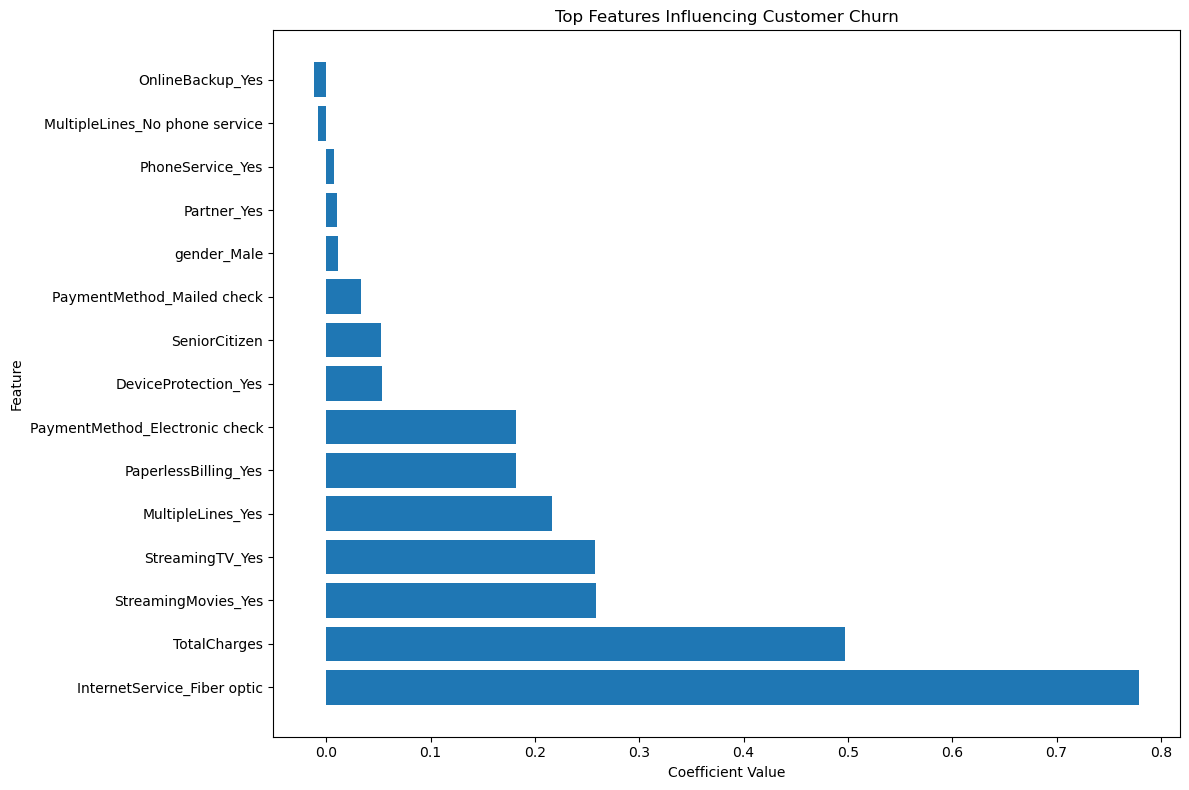

In [128]:
import matplotlib.pyplot as plt

top15 = importance.head(15)

plt.figure(figsize=(12,8))

plt.barh(
    top15["Feature"],
    top15["Coefficient"]
)

plt.title(
    "Top Features Influencing Customer Churn"
)

plt.xlabel("Coefficient Value")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

In [129]:
importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [130]:
import joblib

joblib.dump(
    X_temp.columns.tolist(),
    "../models/feature_names.pkl"
)

['../models/feature_names.pkl']

In [131]:
X_shap = X.drop(
    columns=[
        "AvgRevenue",
        "TenureGroup_1-2 Years",
        "TenureGroup_2-4 Years",
        "TenureGroup_4-6 Years"
    ]
)

In [132]:
print(X_shap.shape)
print(lr.coef_.shape)

(7043, 30)
(1, 30)


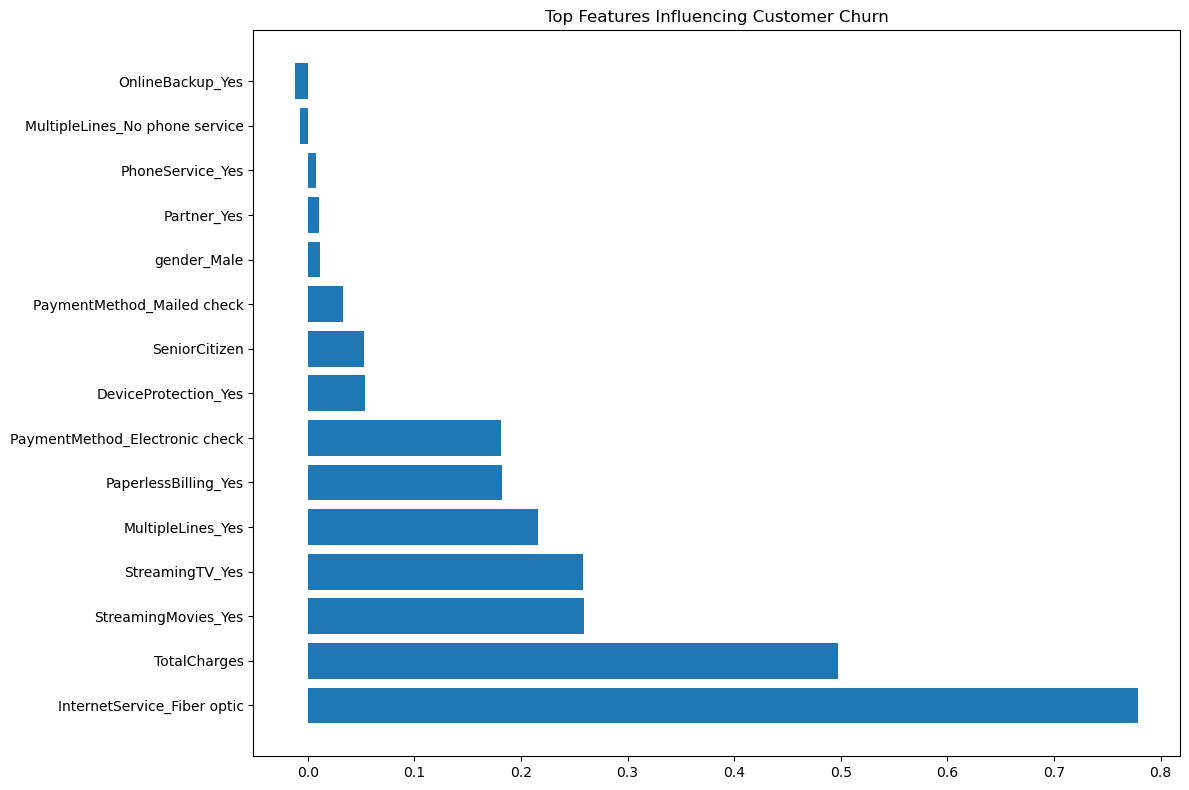

In [133]:
plt.figure(figsize=(12,8))

plt.barh(
    importance.head(15)["Feature"],
    importance.head(15)["Coefficient"]
)

plt.title(
    "Top Features Influencing Customer Churn"
)

plt.tight_layout()

plt.show()